<a href="https://colab.research.google.com/github/HLZHarry/Alpha-Lens-TPM/blob/main/04_Backtest_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.  The Brain (XGBoost): We use a Gradient Boosted Tree model to find the mathematical relationship between your features (Momentum, Volatility, AI Sentiment) and the future return.

2.  The Proof (Backtest): We simulate how a portfolio would have performed if it followed the AI's "buy/sell" signals in the real world.

📈 The Expected Outcome

A Comparison Chart (Equity Curve). You should see two lines:

1. The Benchmark (Gray/Dotted): The "Buy and Hold" return of your stock universe.

2. The Hybrid Strategy (Blue/Solid): Your AI-driven portfolio.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from google.colab import drive

In [2]:
# 1. Load the golden dataset
drive.mount('/content/drive')
path = "/content/drive/MyDrive/Alpha-Lens-Project"
df = pd.read_csv(f"{path}/final_hybrid_data.csv")
df['Date'] = pd.to_datetime(df['Date'])

Mounted at /content/drive


In [3]:
df.head(5)

,Date,Ticker,Price,Log_Return,Momentum_1M,Vol_1M,Target_Next_Return,AI_Sentiment
0,2021-02-02,CNR.TO,122.043640,0.026020,-0.035841,0.018252,-0.009968,0.0
1,2021-02-02,CP.TO,87.299812,0.043296,0.029244,0.023344,-0.011101,0.0
2,2021-02-02,RY.TO,87.831017,0.010848,0.019429,0.008294,-0.001136,0.0
3,2021-02-02,SHOP.TO,158.132004,0.071332,0.124513,0.032529,-0.012178,0.0
4,2021-02-02,TD.TO,59.424534,0.015684,0.037561,0.010373,0.004051,0.0


In [4]:
# 2. Feature Selection
# We use our Momentum, Volatility, and teh OpenAI Sentiment score
features = ['Momentum_1M', 'Vol_1M', 'AI_Sentiment']
target = 'Target_Next_Return'

In [5]:
# 3. Time-Series Split (The 'Gold Standard' for Finance)
# We train on data before 2025 and test on 2025-2026 (The 'Future')
train_df = df[df['Date'] < '2025-01-01'].dropna()
test_df = df[df['Date'] >= '2025-01-01'].copy().dropna()

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

In [6]:
# 4. Train The XGBosst model
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.03,
    subsample = 0.8,
    colsample_bytree=0.8
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [9]:
# 5. Generate Predictions & Strategy
test_df['Predicted_Return'] = model.predict(X_test)

# Strategy Logic: If prediction is positive, go 'Long' (1), else Cash (0)
test_df['Signal'] = np.where(test_df['Predicted_Return'] > 0, 1, 0)
test_df['Strategy_Return'] = test_df['Signal'] * test_df['Log_Return']

In [10]:
# 6. Calculate Cumulative Returns (Performance)
# Group by date to see the Average performance
market_performance = test_df.groupby('Date')['Log_Return'].mean().cumsum().apply(np.exp)
strategy_performance = test_df.groupby('Date')['Strategy_Return'].mean().cumsum().apply(np.exp)

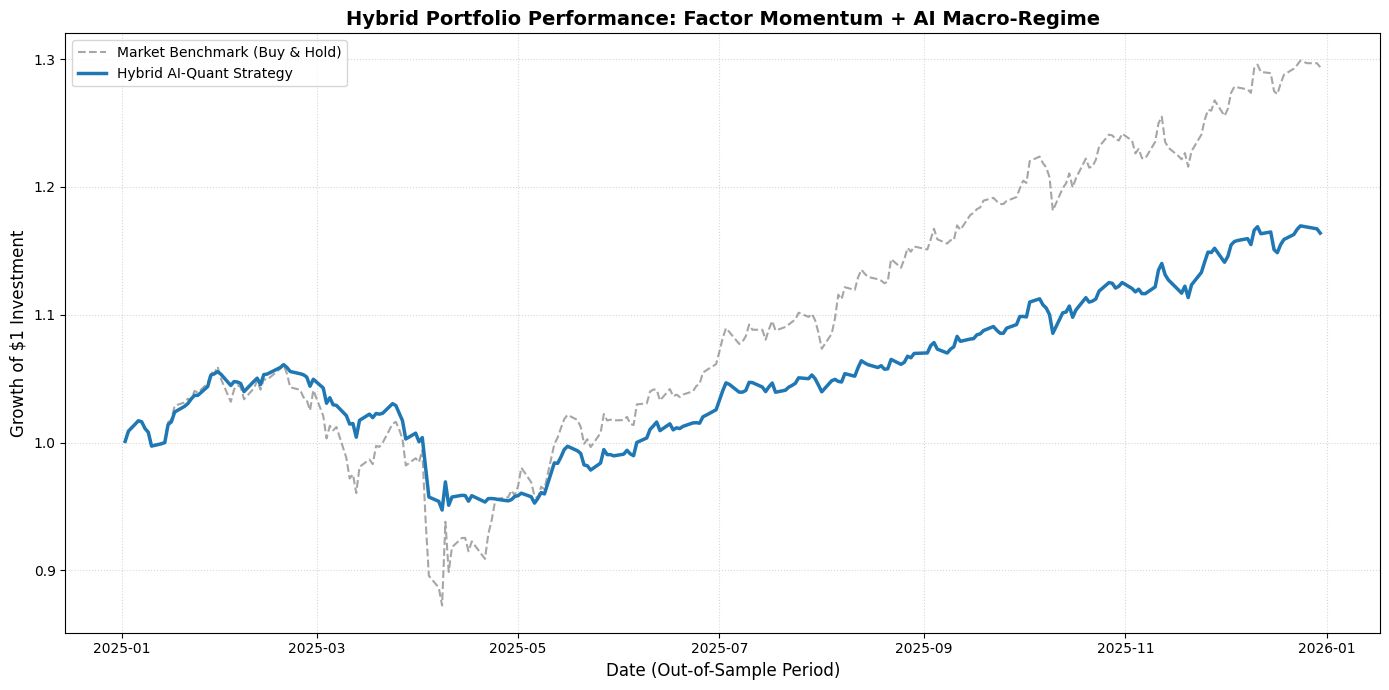

In [11]:
# 7. THE FINAL VISUALIZATION
plt.figure(figsize=(14, 7), facecolor='white')
plt.plot(market_performance, label='Market Benchmark (Buy & Hold)', color='gray', linestyle='--', alpha=0.7)
plt.plot(strategy_performance, label='Hybrid AI-Quant Strategy', color='#1f77b4', linewidth=2.5)

plt.title('Hybrid Portfolio Performance: Factor Momentum + AI Macro-Regime', fontsize=14, fontweight='bold')
plt.xlabel('Date (Out-of-Sample Period)', fontsize=12)
plt.ylabel('Growth of $1 Investment', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
# 8. OUTPUT METRICS
total_return = (strategy_performance.iloc[-1] - 1) * 100
market_return = (market_performance.iloc[-1] - 1) * 100
print(f"Total Strategy Return: {total_return:.2f}%")
print(f"Total Market Return: {market_return:.2f}%")

Total Strategy Return: 16.38%
Total Market Return: 29.37%
